In [3]:
import sqlalchemy
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import matplotlib.ticker as ticker 
from sklearn.cluster import KMeans
from datetime import datetime
from pytz import timezone

In [4]:
dataTrain = pd.read_csv("../data/Train_knight.csv")


In [10]:

# group data by knight
# apply function is used to apply a function to each group 
# lambda x : x is a function that returns the group itself 
# in this case, the group is the knight
knight = dataTrain.groupby('knight').apply(lambda x : x)
# print(knight)

knight           1.000000
Empowered        0.793652
Prescience       0.790066
Stims            0.786797
Recovery         0.777633
Sprint           0.739672
Strength         0.737403
Sensitivity      0.721566
Power            0.700709
Awareness        0.699662
Attunement       0.648893
Dexterity        0.631987
Delay            0.598072
Slash            0.550663
Pull             0.537800
Lightsaber       0.515340
Evade            0.465605
Hability         0.446632
Burst            0.445847
Combo            0.445223
Blocking         0.421950
Agility          0.397458
Reactivity       0.375103
Grasping         0.350105
Repulse          0.324399
Friendship       0.236633
Mass             0.113185
Midi-chlorien    0.008132
Push            -0.019446
Deflection      -0.026489
Survival        -0.043099
Name: knight, dtype: float64


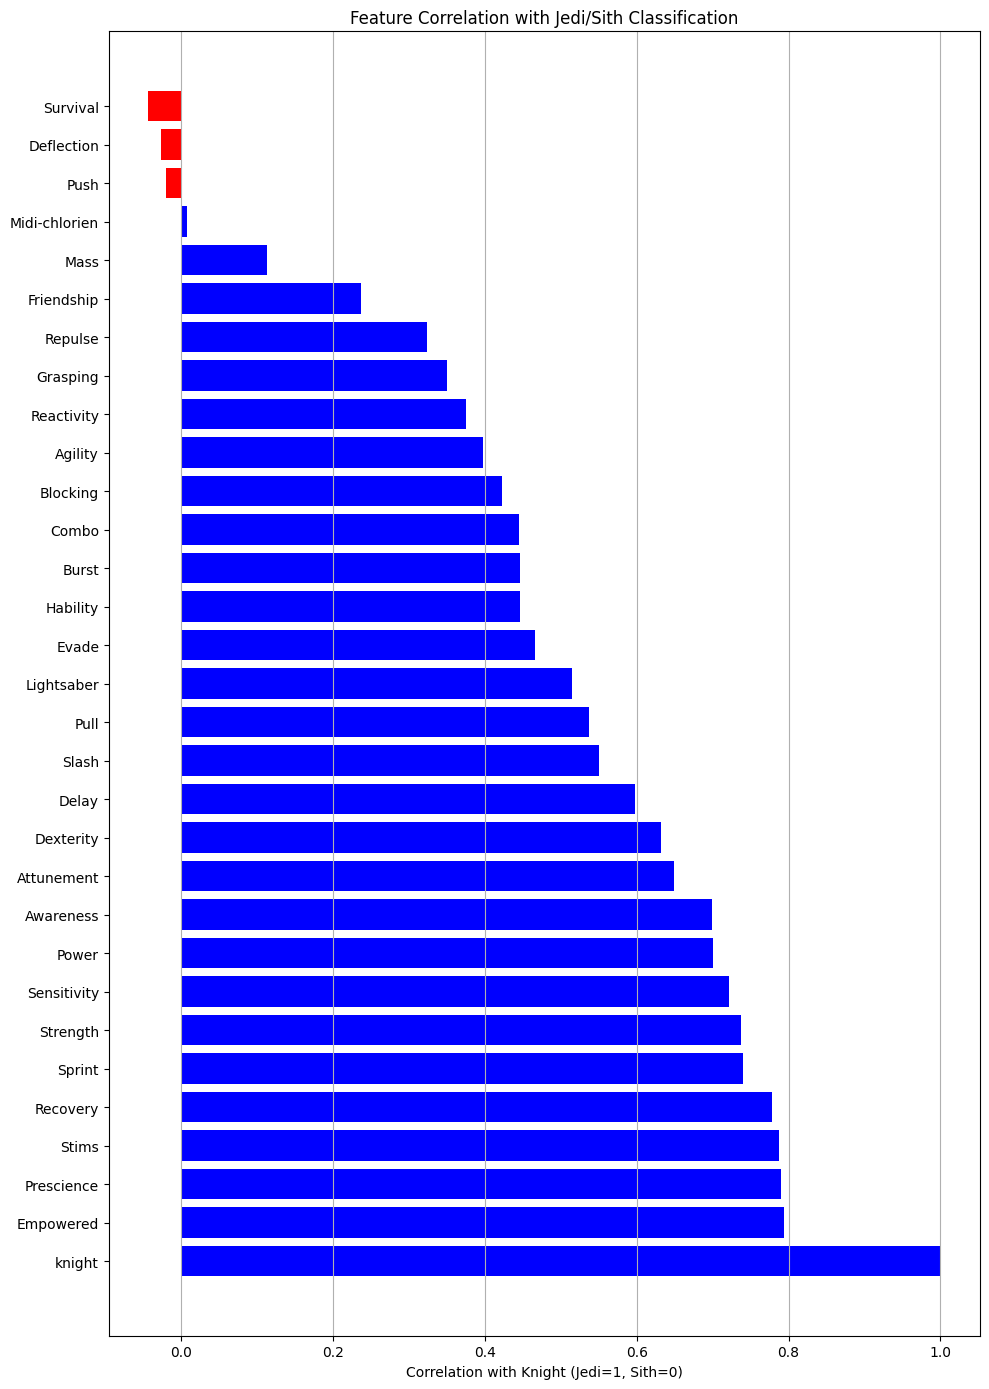

Friendship column found:
Friendship: 0.23663283691484505


In [12]:
# Replace 'knight' values: 'Jedi' becomes 1, 'Sith' becomes 0
# because we want to find the correlation between 'knight' and other features
# we need to convert 'knight' to a numerical value
cor = knight.replace({'knight': 'Jedi'}, 1)
cor = cor.replace({'knight': 'Sith'}, 0)

# Calculate correlation matrix between all features
cor = cor.corr()

# Sort the correlation matrix by the 'knight' column in descending order
# This helps identify features most correlated with being a Jedi (positive values)
# or most correlated with being a Sith (negative values)
cor = cor.sort_values(by='knight', ascending=False)

# Print the correlation values for the 'knight' column
# This shows how each feature correlates with being a Jedi (positive) or Sith (negative)
# Print the correlation values for the 'knight' column
# This shows how each feature correlates with being a Jedi (positive) or Sith (negative)
print(cor['knight'].sort_values(ascending=False))
# Visualize the correlation with knight in a horizontal bar plot
plt.figure(figsize=(10, 14))
plt.barh(cor.index, cor['knight'], color=['blue' if x > 0 else 'red' for x in cor['knight']])
plt.xlabel('Correlation with Knight (Jedi=1, Sith=0)')
plt.title('Feature Correlation with Jedi/Sith Classification')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

# Check specifically for the 'Friendship' correlation (might be capitalized differently)
friend_cols = [col for col in cor.index if 'friend' in col.lower()]
if friend_cols:
    print("Friendship column found:")
    for col in friend_cols:
        print(f"{col}: {cor.loc[col, 'knight']}")
else:
    print("No 'friendship' column found in correlation matrix")